In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cd.utils.plotting import plot_contours
from cd.algs.cd_poly import CDPolynomial

from sklearn.datasets import make_blobs

In [2]:
from scipy.spatial.distance import cdist

def k(X, Y, sigma):
    d = cdist(X, Y, metric='euclidean')  # shape (n_X, n_Y)
    return np.exp(-d / sigma)

def k(x, y, d):
    """
    x: (A, dim)
    y: (B, dim)
    return: (A, B)
    """
    return (1 + x @ y.T) ** d

class CDPoly():
    def __init__(self, X, deg):
        self.X = X
        self.deg = deg
        self.K = k(X, X, deg) + 1e-6 * np.eye(len(X), len(X)) # (n_data, n_data)
        self.mean = self(X).mean()

    def __call__(self, x):
        "x: (batch, dim)"
        k_x = k(x, self.X, self.deg) # (batch, n_data)
        y = np.linalg.solve(self.K, k_x.T).T # (batch, n_data)
        return np.einsum('bi,bi->b', k_x, y) * len(self.X)
    
    def plot(self, ax, multiplier=1., **plot_kwargs):
        levels = [multiplier * self.mean * 10 ** i for i in range(10)]
        plot_contours(self, ax, levels=levels, **plot_kwargs)


In [3]:
x = make_blobs(100)[0]

In [4]:
p.mean

NameError: name 'p' is not defined

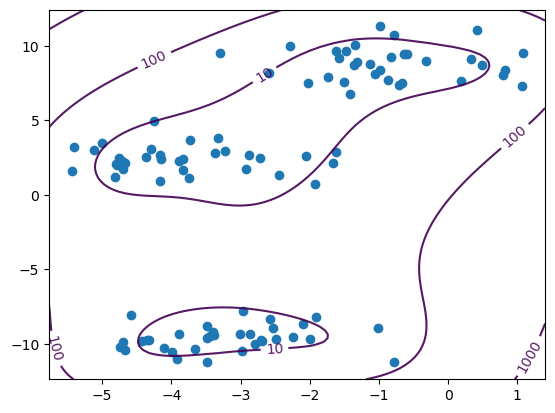

In [8]:
p = CDPolynomial(x, degree=3)
plt.scatter(*x.T)
p.plot(plt.gca())